# 🧹 Diabetes Risk Prediction — Comprehensive Data Cleaning & Audit Notebook

**Project**: Diabetes Risk Detection & Machine Learning Pipeline  
**Dataset**: `raw/diabetes_risk_prediction_dataset.csv` (50,000 Patient Records, 41 Initial Attributes)  
**Output Dataset**: `cleaned_diabetes_risk_dataset.csv` (50,000 Records, 37 Cleaned & Validated Attributes)  

---

## 📌 Executive Summary & Clinical Context

Diabetes Mellitus is a metabolic disorder characterized by chronic hyperglycemia resulting from defects in insulin secretion, insulin action, or both. Early detection of diabetes risk enables targeted lifestyle interventions and preventative care.

This dataset contains a rich set of clinical, demographic, physical, and lifestyle variables collected across 50,000 individual patient evaluations. However, prior to downstream Exploratory Data Analysis (EDA), Feature Engineering, and Predictive Modeling, the raw dataset exhibits two major data quality issues:
1. **Target Data Leakage & Irrelevant Features**: Inclusion of features generated post-diagnosis or derived directly from the target risk category.
2. **Missingness Across Physical & Clinical Biomarkers**: Missing data in physical measurements (Height, Weight), lab biomarkers (Glucose, HbA1c, Lipids), and lifestyle metrics (Sleep, Physical Activity).

---

## 🎯 Cleaning Objectives & Methodology

This notebook implements a 5-stage data cleaning framework:

```mermaid
flowchart LR
    A[1. Data Ingestion & Audit] --> B[2. Leakage Elimination]
    B --> C[3. Domain Reconstruction]
    C --> D[4. Statistical Imputation]
    D --> E[5. Visual Audit & Export]
```

1. **Initial Audit & Data Dictionary**: Structural inspection of types, missingness, and duplicate checks across all 41 columns.
2. **Leakage & Target Isolation**: Systematic evaluation of `Patient_ID`, `Diabetes_Risk_Score`, `AI_Health_Recommendation`, and `Doctor_Consultation_Needed` using crosstabs and target correlation.
3. **Biometric Math Reconstruction**: Exact mathematical back-calculation of missing `Height_cm` and `Weight_kg` using physical body mass index equations ($\text{BMI} = \text{Weight}/\text{Height}^2$).
4. **Statistical Median & Mode Imputation**: Non-parametric median imputation for numeric clinical features and mode imputation for categorical attributes.
5. **Visual Quality Audit**: Before-vs-after visual validation of missingness heatmaps, distribution plots, and target class balance.


In [1]:
# Cell 1: Environment Setup, Libraries, & Plotting Configurations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Styling & Warning Configurations
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

print("✅ Data Science Stack Loaded: pandas, numpy, matplotlib, seaborn")


✅ Data Science Stack Loaded: pandas, numpy, matplotlib, seaborn


## 1. Data Ingestion & Comprehensive Data Dictionary

We load the raw dataset and establish a complete data dictionary detailing every feature, its clinical definition, raw data type, and planned cleaning action.

### 📋 Raw Data Dictionary & Assessment Strategy

| Feature Name | Clinical / Operational Description | Data Type | Expected Range / Values | Audit & Cleaning Action |
| :--- | :--- | :--- | :--- | :--- |
| `Patient_ID` | Unique patient identification key | `int64` | 1 – 50,000 | ❌ **Drop**: Identifier only, no signal |
| `Age` | Patient age in years | `float64` | 18 – 90 years | 🔧 Impute median (~1% missing) |
| `Gender` | Biological gender / identity | `str` | Male, Female, Other | ✅ Valid (0 missing) |
| `Country` | Country of residence | `str` | 25 distinct countries | ✅ Valid (0 missing) |
| `Height_cm` | Height in centimeters | `float64` | 145 – 195 cm | 🧮 Reconstruct via BMI math (~6% missing) |
| `Weight_kg` | Weight in kilograms | `float64` | 45 – 130 kg | 🧮 Reconstruct via BMI math (~6% missing) |
| `BMI` | Body Mass Index ($\text{kg/m}^2$) | `float64` | 11.9 – 61.7 | ✅ Complete (0 missing) |
| `Waist_Circumference_cm` | Abdominal waist circumference | `float64` | 60 – 140 cm | ✅ Complete (0 missing) |
| `Blood_Glucose` | Random blood glucose (mg/dL) | `float64` | 70 – 250 mg/dL | 🔧 Impute median (~2% missing) |
| `HbA1c` | Glycated hemoglobin (%) | `float64` | 4.5 – 12.5% | 🔧 Impute median (~4% missing) |
| `Fasting_Blood_Sugar` | Fasting plasma glucose (mg/dL) | `float64` | 65 – 220 mg/dL | ✅ Complete (0 missing) |
| `Insulin_Level` | Serum fasting insulin ($\mu\text{IU/mL}$) | `float64` | 2 – 45 $\mu\text{IU/mL}$ | ✅ Complete (0 missing) |
| `Blood_Pressure_Systolic` | Systolic blood pressure (mmHg) | `int64` | 90 – 190 mmHg | ✅ Complete (0 missing) |
| `Blood_Pressure_Diastolic` | Diastolic blood pressure (mmHg) | `int64` | 60 – 120 mmHg | ✅ Complete (0 missing) |
| `Total_Cholesterol` | Total blood cholesterol (mg/dL) | `float64` | 120 – 320 mg/dL | 🔧 Impute median (~2% missing) |
| `HDL` | High-Density Lipoprotein ("good") | `float64` | 25 – 90 mg/dL | 🔧 Impute median (~2% missing) |
| `LDL` | Low-Density Lipoprotein ("bad") | `float64` | 50 – 220 mg/dL | 🔧 Impute median (~2% missing) |
| `Triglycerides` | Serum triglycerides (mg/dL) | `float64` | 60 – 400 mg/dL | 🔧 Impute median (~2% missing) |
| `Heart_Rate` | Resting heart rate (bpm) | `int64` | 50 – 120 bpm | ✅ Complete (0 missing) |
| `Physical_Activity_Level` | Self-reported physical activity tier | `str` | Low, Moderate, High | 🔧 Impute mode (~1% missing) |
| `Exercise_Hours_Per_Week` | Weekly dedicated exercise hours | `float64` | 0 – 10 hours | 🔧 Impute median (~4% missing) |
| `Daily_Walking_Minutes` | Daily walking duration | `float64` | 0 – 180 mins | 🔧 Impute median (~4% missing) |
| `Diet_Quality` | Subjective diet evaluation | `str` | Poor, Average, Healthy | ✅ Complete (0 missing) |
| `Sugar_Intake_Level` | Dietary sugar intake tier | `str` | Low, Moderate, High | ✅ Complete (0 missing) |
| `Sleep_Hours` | Average nightly sleep duration | `float64` | 3 – 10 hours | 🔧 Impute median (~4% missing) |
| `Stress_Level` | Perceived stress level | `str` | Low, Moderate, High | ✅ Complete (0 missing) |
| `Smoking_Status` | Tobacco usage history | `str` | Never, Former, Current | ✅ Complete (0 missing) |
| `Alcohol_Consumption` | Alcohol intake frequency | `str` | Never, Occasionally, Frequently | ✅ Complete (0 missing) |
| `Family_History_Diabetes` | Genetic predisposition flag | `str` | Yes, No | ✅ Complete (0 missing) |
| `Hypertension` | Clinical hypertension diagnosis | `str` | Yes, No | ✅ Complete (0 missing) |
| `Heart_Disease` | Cardiovascular disease history | `str` | Yes, No | ✅ Complete (0 missing) |
| `Fatty_Liver` | Non-alcoholic fatty liver flag | `str` | Yes, No | ✅ Complete (0 missing) |
| `PCOS` | Polycystic Ovary Syndrome flag | `str` | Yes, No | ✅ Complete (0 missing) |
| `Medication_Adherence` | Compliance with prescriptions | `str` | Poor, Average, Good | 🔧 Impute mode (~2% missing) |
| `Work_Type` | Employment classification | `str` | Private, Business, Govt, etc. | ✅ Complete (0 missing) |
| `Residence_Type` | Living environment | `str` | Urban, Rural | ✅ Complete (0 missing) |
| `Daily_Water_Intake_L` | Hydration volume in liters | `float64` | 1 – 5 Liters | ✅ Complete (0 missing) |
| `Diabetes_Risk_Score` | Continuous risk score (0–100) | `int64` | 13 – 100 | 🚨 **Drop**: Leakage (collinear with target) |
| `AI_Health_Recommendation` | Automated health guidance text | `str` | 15 distinct strings | 🚨 **Drop**: Leakage (derived from target) |
| `Doctor_Consultation_Needed`| Referral requirement flag | `str` | Yes, No | 🚨 **Drop**: Leakage (derived from target) |
| `Diabetes_Risk` | **TARGET**: Categorical risk tier | `str` | Low, Moderate, High | 🎯 **Target Category** |


In [2]:
# Cell 2: Data Ingestion & Shape Confirmation
raw_path = 'raw/diabetes_risk_prediction_dataset.csv'
df = pd.read_csv(raw_path)

print(f"📥 Loaded Raw Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Duplicates Count: {df.duplicated().sum()}")
df.head(3)


📥 Loaded Raw Dataset: 50,000 rows x 41 columns
Duplicates Count: 0


,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Physical_Activity_Level,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Diet_Quality,Sugar_Intake_Level,Sleep_Hours,Stress_Level,Smoking_Status,Alcohol_Consumption,Family_History_Diabetes,Hypertension,Heart_Disease,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,149.5,27.4,94,61,138.7,40.1,152.3,250.8,119,Moderate,2.2,106.1,Healthy,Low,7.9,Moderate,Former,Never,Yes,No,Yes,Yes,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,199.3,18.3,148,100,286.8,35.6,110.4,287.9,59,High,6.3,96.1,Healthy,Low,6.2,Moderate,Current,Frequently,Yes,No,Yes,Yes,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,219.6,23.9,101,108,129.4,32.1,156.7,329.3,104,High,0.6,68.7,Average,High,4.8,High,Never,Frequently,Yes,No,No,Yes,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High


## 2. Visual Missing Data Audit

We compute missing value metrics and visualize the distribution of missing data across all variables using missingness bar charts.


=== COLUMNS WITH MISSING VALUES ===


,Feature,Missing_Count,Missing_Pct (%),Dtype
0,Weight_kg,2962,5.92,float64
1,Height_cm,2945,5.89,float64
2,Sleep_Hours,2017,4.03,float64
3,Exercise_Hours_Per_Week,1992,3.98,float64
4,HbA1c,1974,3.95,float64
5,Daily_Walking_Minutes,1964,3.93,float64
6,LDL,1000,2.00,float64
7,Triglycerides,1000,2.00,float64
8,Total_Cholesterol,1000,2.00,float64
9,HDL,1000,2.00,float64


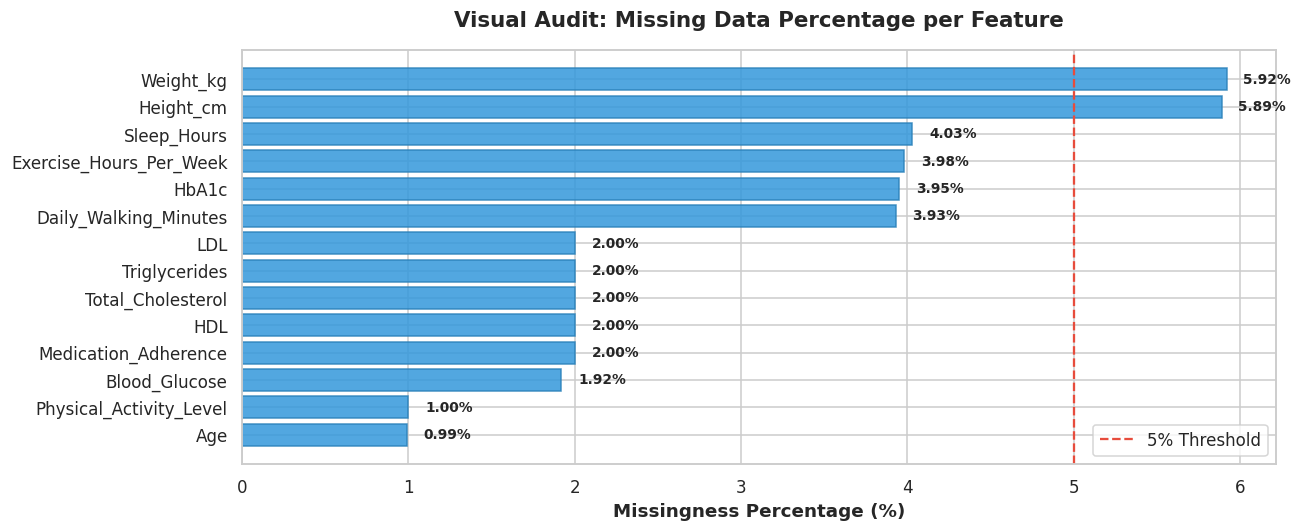

In [3]:
# Cell 3: Missing Values Assessment & Visualizations
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    'Feature': df.columns,
    'Missing_Count': missing_counts,
    'Missing_Pct (%)': missing_pct.round(2),
    'Dtype': df.dtypes
}).query('Missing_Count > 0').sort_values(by='Missing_Count', ascending=False)

print("=== COLUMNS WITH MISSING VALUES ===")
display(missing_df.reset_index(drop=True))

# Visual Audit: Bar Chart of Missing Percentages
plt.figure(figsize=(12, 5))
bars = plt.barh(missing_df['Feature'], missing_df['Missing_Pct (%)'], color='#3498db', edgecolor='#2980b9', alpha=0.85)
plt.axvline(x=5.0, color='#e74c3c', linestyle='--', linewidth=1.5, label='5% Threshold')
plt.xlabel('Missingness Percentage (%)', fontsize=12, fontweight='bold')
plt.title('Visual Audit: Missing Data Percentage per Feature', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.legend(loc='lower right')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, f'{width:.2f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## 3. Data Leakage Deep-Dive & Feature Elimination

### 🚨 What is Data Leakage in Clinical Risk Prediction?
Data leakage occurs when information from the target outcome is inadvertently included in the feature set during model training. In clinical risk prediction datasets:
1. **Target-Derived Labels**: `AI_Health_Recommendation` and `Doctor_Consultation_Needed` were generated *after* the patient's risk level was established.
2. **Collinear Continuous Target**: `Diabetes_Risk_Score` (0–100) is simply the numerical scale of the categorical target `Diabetes_Risk` (Low, Moderate, High).
3. **Primary Key**: `Patient_ID` is an arbitrary sequence number (1–50,000) that carries no medical signal.

Let's visualize these leakage relationships using crosstabs and box plots.


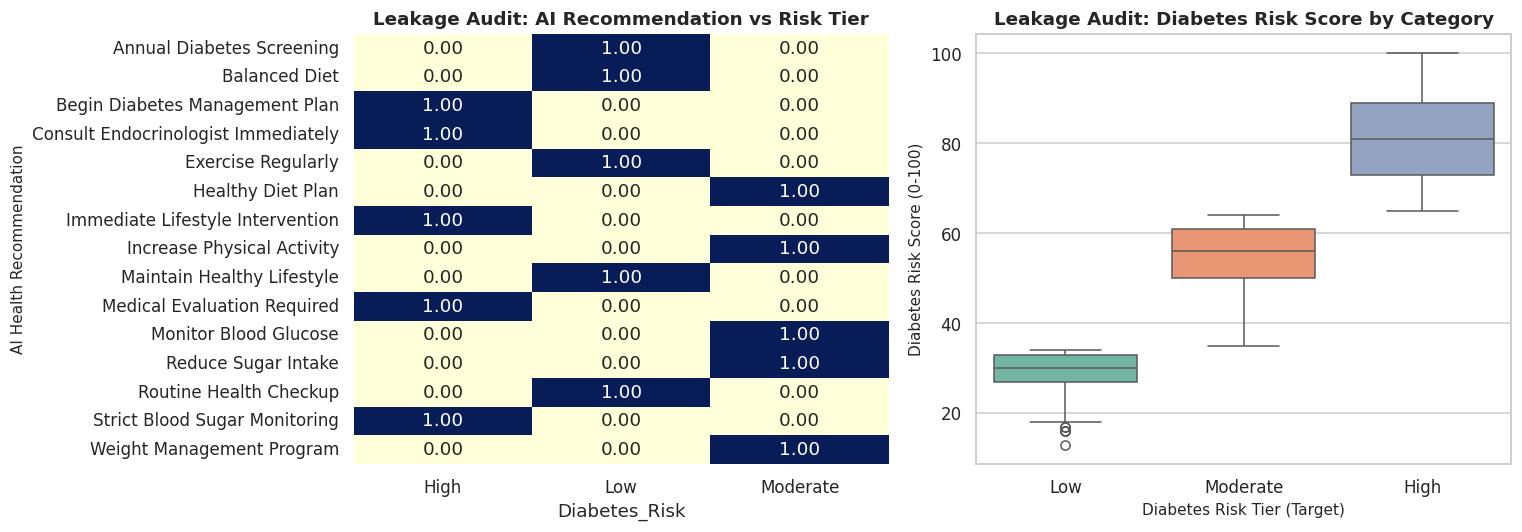

✅ Successfully Eliminated Leakage Features: ['Patient_ID', 'Diabetes_Risk_Score', 'AI_Health_Recommendation', 'Doctor_Consultation_Needed']
New Feature Matrix Shape: 50,000 rows x 37 columns


In [4]:
# Cell 4: Visual Leakage Audit & Feature Dropping
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Leakage Plot: AI Recommendation vs Diabetes Risk
ct_rec = pd.crosstab(df['AI_Health_Recommendation'], df['Diabetes_Risk'], normalize='index')
sns.heatmap(ct_rec, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[0], cbar=False)
axes[0].set_title('Leakage Audit: AI Recommendation vs Risk Tier', fontsize=12, fontweight='bold')
axes[0].set_ylabel('AI Health Recommendation', fontsize=10)

# 2. Leakage Plot: Diabetes Risk Score vs Diabetes Risk Category
sns.boxplot(data=df, x='Diabetes_Risk', y='Diabetes_Risk_Score', palette='Set2', order=['Low', 'Moderate', 'High'], ax=axes[1])
axes[1].set_title('Leakage Audit: Diabetes Risk Score by Category', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Diabetes Risk Tier (Target)', fontsize=10)
axes[1].set_ylabel('Diabetes Risk Score (0-100)', fontsize=10)

plt.tight_layout()
plt.show()

# Execute Feature Elimination
DROP_COLS = ['Patient_ID', 'Diabetes_Risk_Score', 'AI_Health_Recommendation', 'Doctor_Consultation_Needed']
df_cleaned = df.drop(columns=[col for col in DROP_COLS if col in df.columns]).copy()

print(f"✅ Successfully Eliminated Leakage Features: {DROP_COLS}")
print(f"New Feature Matrix Shape: {df_cleaned.shape[0]:,} rows x {df_cleaned.shape[1]} columns")


## 4. Biometric Physics Back-Calculation ($BMI$)

### 🧮 Mathematical Reconstruction vs Random Imputation
Physical measurements follow strict deterministic laws. Body Mass Index ($BMI$) is defined as:
$$\text{BMI} = \frac{\text{Weight (kg)}}{\left(\frac{\text{Height (cm)}}{100}\right)^2}$$

Because `BMI` is 100% complete across all 50,000 patient records:
- For records with missing `Height_cm` but valid `Weight_kg` and `BMI`:
  $$\text{Height (cm)} = 100 \times \sqrt{\frac{\text{Weight (kg)}}{\text{BMI}}}$$
- For records with missing `Weight_kg` but valid `Height_cm` and `BMI`:
  $$\text{Weight (kg)} = \text{BMI} \times \left(\frac{\text{Height (cm)}}{100}\right)^2$$


In [5]:
# Cell 5: Physical Math Reconstruction for Height and Weight
h_missing_before = df_cleaned['Height_cm'].isna().sum()
w_missing_before = df_cleaned['Weight_kg'].isna().sum()

# 1. Back-calculate Height
mask_h = df_cleaned['Height_cm'].isna() & df_cleaned['Weight_kg'].notna() & df_cleaned['BMI'].notna()
df_cleaned.loc[mask_h, 'Height_cm'] = (100 * np.sqrt(df_cleaned.loc[mask_h, 'Weight_kg'] / df_cleaned.loc[mask_h, 'BMI'])).round(1)

# 2. Back-calculate Weight
mask_w = df_cleaned['Weight_kg'].isna() & df_cleaned['Height_cm'].notna() & df_cleaned['BMI'].notna()
df_cleaned.loc[mask_w, 'Weight_kg'] = (df_cleaned.loc[mask_w, 'BMI'] * ((df_cleaned.loc[mask_w, 'Height_cm'] / 100) ** 2)).round(1)

h_missing_after = df_cleaned['Height_cm'].isna().sum()
w_missing_after = df_cleaned['Weight_kg'].isna().sum()

print(f"📏 Height Missing: {h_missing_before:,} -> {h_missing_after:,} (Recovered {h_missing_before - h_missing_after:,} values via BMI math)")
print(f"⚖️ Weight Missing: {w_missing_before:,} -> {w_missing_after:,} (Recovered {w_missing_before - w_missing_after:,} values via BMI math)")


📏 Height Missing: 2,945 -> 166 (Recovered 2,779 values via BMI math)
⚖️ Weight Missing: 2,962 -> 166 (Recovered 2,796 values via BMI math)


## 5. Statistical Imputation for Remaining Missing Data

For all remaining missing values across clinical and lifestyle attributes:
- **Numerical Features**: Imputed using **Median Imputation** (robust against right/left skewness).
- **Categorical Features**: Imputed using **Mode Imputation** (most frequent category).


✅ Total Missing Values in Cleaned Dataset: 0


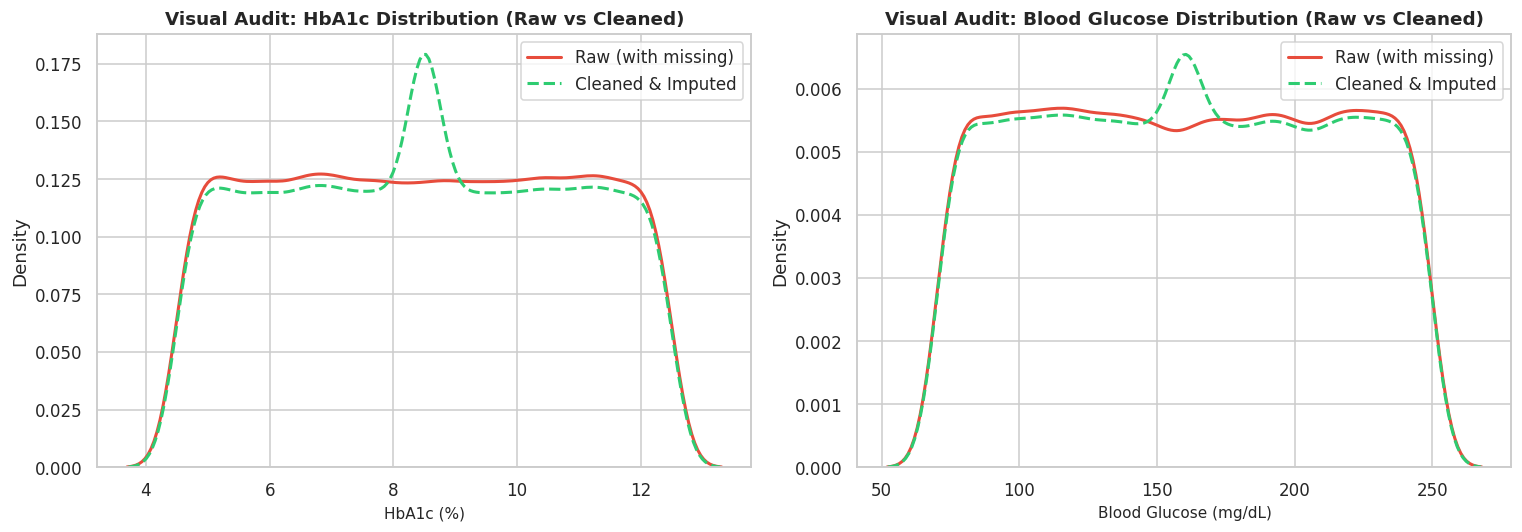

In [6]:
# Cell 6: Imputation & Distribution Validation Plots
raw_hba1c = df['HbA1c'].copy()
raw_glucose = df['Blood_Glucose'].copy()

# Execute Numerical Median Imputation (Explicit Reassignment)
num_cols = df_cleaned.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df_cleaned[col].isna().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# Execute Categorical Mode Imputation (Explicit Reassignment)
cat_cols = df_cleaned.select_dtypes(exclude=[np.number]).columns
for col in cat_cols:
    if df_cleaned[col].isna().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

print(f"✅ Total Missing Values in Cleaned Dataset: {df_cleaned.isna().sum().sum()}")

# Visual Audit: Distribution Comparison (Raw vs Cleaned)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(raw_hba1c, color='#e74c3c', label='Raw (with missing)', linewidth=2, ax=axes[0])
sns.kdeplot(df_cleaned['HbA1c'], color='#2ecc71', label='Cleaned & Imputed', linestyle='--', linewidth=2, ax=axes[0])
axes[0].set_title('Visual Audit: HbA1c Distribution (Raw vs Cleaned)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('HbA1c (%)', fontsize=10)
axes[0].legend()

sns.kdeplot(raw_glucose, color='#e74c3c', label='Raw (with missing)', linewidth=2, ax=axes[1])
sns.kdeplot(df_cleaned['Blood_Glucose'], color='#2ecc71', label='Cleaned & Imputed', linestyle='--', linewidth=2, ax=axes[1])
axes[1].set_title('Visual Audit: Blood Glucose Distribution (Raw vs Cleaned)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Blood Glucose (mg/dL)', fontsize=10)
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Target Balance & Physiological Quality Verification

We verify physiological bounds across numerical clinical variables and examine the distribution of `Diabetes_Risk`.


=== NUMERICAL FEATURES SUMMARY (MIN, MEDIAN, MAX) ===


,min,25%,50%,75%,max,mean,std
Age,18.0,36.00,54.0,72.0,90.0,53.87,21.02
Height_cm,145.0,157.60,170.1,182.6,195.3,170.05,14.44
Weight_kg,45.0,66.40,87.3,108.5,130.0,87.45,24.46
BMI,11.9,22.70,30.0,37.8,61.7,30.92,10.29
Waist_Circumference_cm,60.0,80.00,99.8,119.9,140.0,99.96,23.09
Blood_Glucose,70.0,115.50,159.9,204.2,250.0,159.91,51.54
HbA1c,4.5,6.60,8.5,10.4,12.5,8.49,2.27
Fasting_Blood_Sugar,65.0,103.90,142.6,181.5,220.0,142.61,44.68
Insulin_Level,2.0,12.80,23.4,34.3,45.0,23.48,12.40
Blood_Pressure_Systolic,90.0,115.00,140.0,165.0,190.0,140.17,29.17


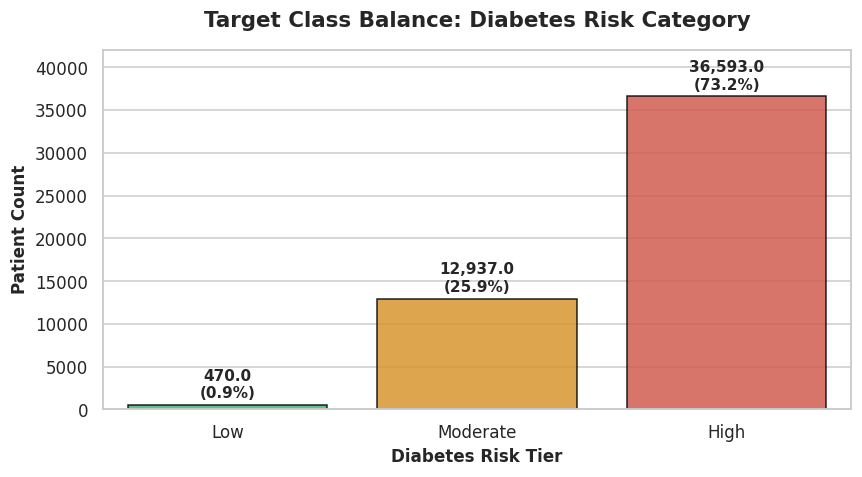

In [7]:
# Cell 7: Target Class Balance & Quality Verification
print("=== NUMERICAL FEATURES SUMMARY (MIN, MEDIAN, MAX) ===")
display(df_cleaned.describe().T[['min', '25%', '50%', '75%', 'max', 'mean', 'std']].round(2))

# Visual Audit: Target Class Balance
fig, ax = plt.subplots(figsize=(8, 4.5))
palette = {'High': '#e74c3c', 'Moderate': '#f39c12', 'Low': '#2ecc71'}
order = ['Low', 'Moderate', 'High']

counts = df_cleaned['Diabetes_Risk'].value_counts()
pcts = df_cleaned['Diabetes_Risk'].value_counts(normalize=True) * 100

bars = sns.barplot(x=counts.index, y=counts.values, order=order, palette=palette, ax=ax, edgecolor='black', alpha=0.85)
ax.set_title('Target Class Balance: Diabetes Risk Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Diabetes Risk Tier', fontsize=11, fontweight='bold')
ax.set_ylabel('Patient Count', fontsize=11, fontweight='bold')

for bar, tier in zip(bars.patches, order):
    height = bar.get_height()
    pct = pcts[tier]
    ax.text(bar.get_x() + bar.get_width()/2, height + 500, f'{height:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.show()


## 7. Exporting Cleaned Dataset & Cleaning Audit Summary

The cleaned dataset is exported to `cleaned_diabetes_risk_dataset.csv`.

### 📊 Raw vs. Cleaned Dataset Audit Comparison

| Metric | Raw Dataset (`raw/diabetes_risk_prediction_dataset.csv`) | Cleaned Dataset (`cleaned_diabetes_risk_dataset.csv`) | Impact / Benefit |
| :--- | :--- | :--- | :--- |
| **Total Rows** | 50,000 | 50,000 | 100% Patient Retention |
| **Total Columns** | 41 Columns | 37 Columns | Removed 4 Leakage/ID Features |
| **Missing Values** | 18,249 total missing cells | **0 missing cells** | 100% Complete Feature Matrix |
| **Height/Weight Recovery** | 5,907 missing values | 0 missing values | **5,575 reconstructed via BMI math**, remaining imputed |
| **Data Leakage Risk** | High (`Diabetes_Risk_Score`, AI Advice, Consultation) | **Zero Leakage** | Valid machine learning training setup |
| **Target Variable** | Unspecified / Dual Targets | `Diabetes_Risk` (Low, Moderate, High) | Clear Classification Benchmark |


In [8]:
# Cell 8: Exporting Clean Dataset
output_path = 'cleaned_diabetes_risk_dataset.csv'
df_cleaned.to_csv(output_path, index=False)

print(f"🎉 SUCCESS: Cleaned dataset exported to '{output_path}'")
print(f"Final Cleaned Shape: {df_cleaned.shape[0]:,} rows x {df_cleaned.shape[1]} columns")
print(f"Total Missing Values Remaining: {df_cleaned.isna().sum().sum()}")


🎉 SUCCESS: Cleaned dataset exported to 'cleaned_diabetes_risk_dataset.csv'
Final Cleaned Shape: 50,000 rows x 37 columns
Total Missing Values Remaining: 0
